In [1]:
# Import required libraries for image recognition and transfer learning
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define dataset location
dataset_path = "data/fruits"

In [3]:
# Load images from folders and automatically create labels from folder names

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 100 files belonging to 5 classes.
Using 80 files for training.
Found 100 files belonging to 5 classes.
Using 20 files for validation.


In [4]:
# Display detected class names
class_names = train_data.class_names
print(class_names)

num_classes = len(class_names)
print("Number of classes:", num_classes)

['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Number of classes: 5


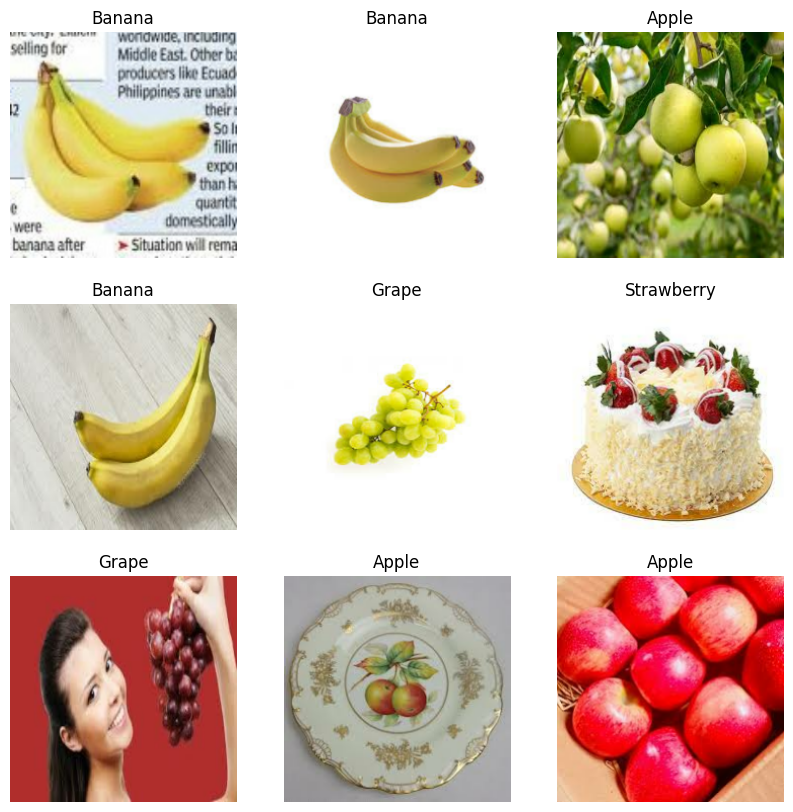

In [5]:
# Display several images from the dataset
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
# Improve loading performance
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
# Load pretrained MobileNetV2 without the top classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# Create custom recognition model
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Preprocess input according to MobileNetV2 requirements
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),

    # Pretrained feature extractor
    base_model,

    # Convert feature maps into vector
    layers.GlobalAveragePooling2D(),

    # Dense layer for classification
    layers.Dense(128, activation="relu"),

    # Dropout to reduce overfitting
    layers.Dropout(0.3),

    # Output layer for multiple fruit classes
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                   │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224 (Functional) │ (None, 7, 7, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 128)              │       163,968 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 5)                │           645 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Compile the model
# Sparse categorical crossentropy is used because labels are integers and we have multiple classes

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
# Train only the custom classification head
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.2750 - loss: 1.7861 - val_accuracy: 0.4500 - val_loss: 1.2906
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6125 - loss: 0.9632 - val_accuracy: 0.7500 - val_loss: 0.8078
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8625 - loss: 0.5155 - val_accuracy: 0.7500 - val_loss: 0.6967
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8875 - loss: 0.3070 - val_accuracy: 0.7500 - val_loss: 0.7392
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 1.0000 - loss: 0.1314 - val_accuracy: 0.7500 - val_loss: 0.8520


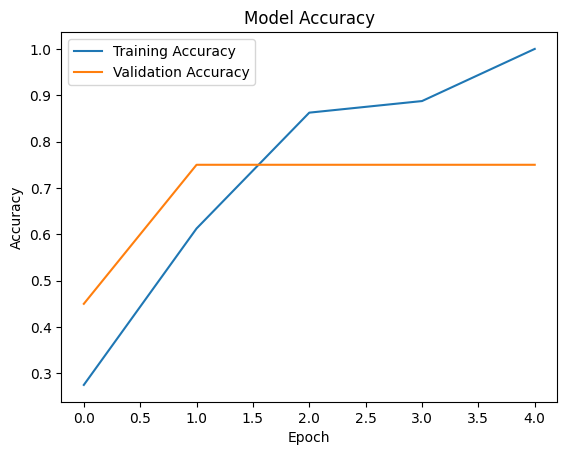

In [10]:
# Plot training and validation accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

In [11]:
# Evaluate model performance
loss, accuracy = model.evaluate(val_data)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.8520
Validation Loss: 0.8520
Validation Accuracy: 75.00%


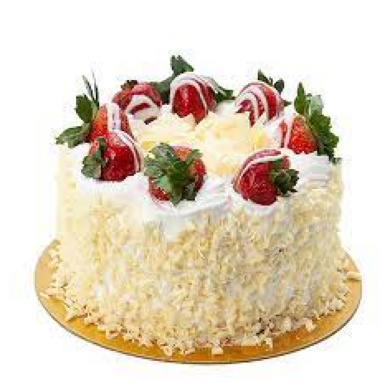

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
Predicted class: Strawberry
Confidence: 95.89%


In [18]:
# Load and recognize one external image

#img_path = "data/fruits/Banana/Banana (2044).jpeg"
img_path = "data/fruits/Strawberry/Strawberry (134).jpeg"
#img_path = "data/fruits/Grape/Grape (567).jpeg"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(224, 224)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
confidence = predictions[0][predicted_index]

print("Predicted class:", class_names[predicted_index])
print(f"Confidence: {confidence * 100:.2f}%")

In [ ]:
# Final Conclusion:
# In this lab, we implemented an image recognition model using transfer learning.
# A pretrained MobileNetV2 model was used as a feature extractor.
# The dataset contained several fruit classes, and the model was trained to recognize the fruit type from an image.
# Images were resized to 224x224 pixels and preprocessed according to MobileNetV2 requirements.
# The pretrained layers were frozen, and only the custom classification layers were trained.
# The model was evaluated using validation accuracy and validation loss.
# The results show that transfer learning is effective for image recognition tasks because it uses features learned from large datasets such as ImageNet.
# Since the dataset was relatively small, the model achieved acceptable results,
# but prediction confidence may vary depending on the input image.

## Comparison with Previous CNN Approach

#In Lab 2, a CNN model was trained from scratch for binary classification.
#In Lab 3, transfer learning was used with MobileNetV2, which already contains pretrained visual features from ImageNet.
#This approach is faster and more effective for small datasets because only the final classification layers are trained.